Project Title

Exploratory Data Analysis (EDA) on Airline Flight Pricing Data

Problem Statement

The objective of this project is to perform Exploratory Data Analysis (EDA) on airline flight data to understand the factors affecting ticket prices, such as airline type, travel class, number of stops, booking time, and route information.

2. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')


3. Load the Airline Dataset

In [4]:
import pandas as pd

df = pd.read_csv(r"D:\All Project\airlines_flights_data.csv")
df.head()



,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


The dataset contains information about domestic airline flights, including pricing, duration, class, and booking details.

4. Dataset Overview

In [5]:
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


Dataset has 300,153 rows and 12 columns

Mix of categorical & numerical variables

No missing values found

5. Data Cleaning & Preparation

In [6]:
df.drop(columns=['index'], inplace=True)


In [7]:
df.isnull().sum()


airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

6. Univariate Analysis

In [9]:
#Airline distribution

df['airline'].value_counts()


airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [15]:
#Travel class distribution

df['class'].value_counts()


class
Economy     206666
Business     93487
Name: count, dtype: int64

In [12]:
#Stops distribution

df['stops'].value_counts()


stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

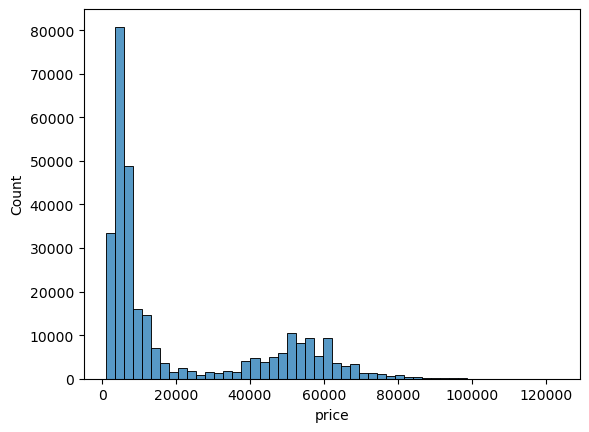

In [13]:
#Price distribution

sns.histplot(df['price'], bins=50)
plt.show()


Interpretation

The price distribution is right-skewed

Most ticket prices are concentrated at the lower range

A few flights have very high prices

Key Findings

Majority of tickets are affordable economy fares

Premium and last-minute bookings increase ticket prices

Ticket prices show high variability

7. Bivariate Analysis

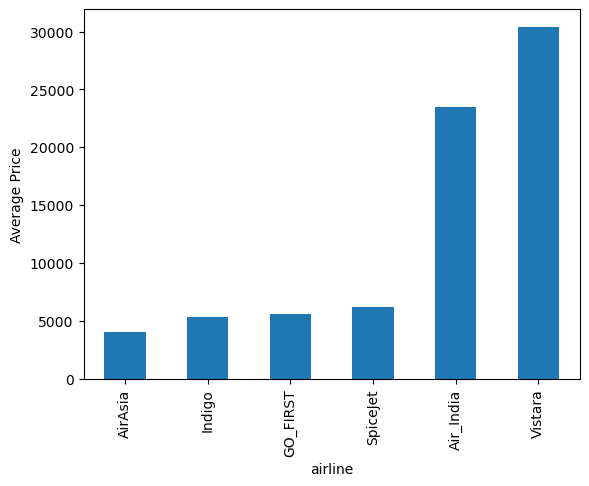

In [18]:
#Airline vs Price

df.groupby('airline')['price'].mean().sort_values().plot(kind='bar')
plt.ylabel('Average Price')
plt.show()


In [ ]:
Interpretation:-

Average ticket price varies significantly across airlines

Full-service airlines show higher average prices

Low-cost carriers have lower average fares

 Key Findings :-

Vistara has the highest average ticket price

Air India is the second most expensive airline

AirAsia offers the lowest average fares

Indigo, Go First, and SpiceJet fall in the mid-price range

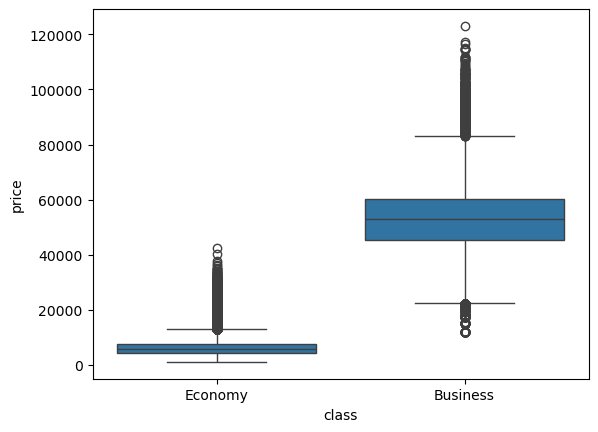

In [19]:
#Class vs Price

sns.boxplot(x='class', y='price', data=df)
plt.show()


Interpretation:-

Ticket prices differ significantly by travel class

Business class prices are much higher than economy class

Business class shows greater price variation

Key Findings:-

Business class tickets are significantly more expensive

Economy class tickets are comparatively affordable

Business class has more high-price outliers

Travel class is a major factor influencing ticket price

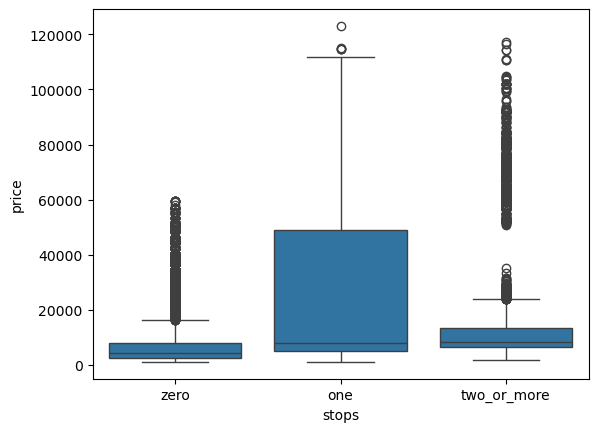

In [20]:
#Stops vs Price

sns.boxplot(x='stops', y='price', data=df)
plt.show()


In [ ]:
Interpretation:-

Ticket prices vary based on the number of stops

Non-stop and multi-stop flights show different price patterns

Flights with more stops have higher price variability

Key Findings:-

Non-stop flights generally have lower median prices

One-stop flights show wide price variation

Two or more stops have many high-price outliers

Number of stops influences ticket pricing

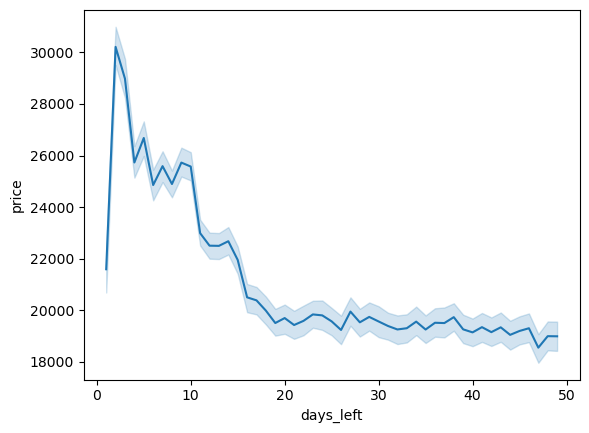

In [22]:
#Days Left vs Price

sns.lineplot(x='days_left', y='price', data=df)
plt.show()


Interpretation:-

Ticket price changes with the number of days left before travel

Prices decrease as days_left increases

Last-minute bookings show higher prices

Key Findings:-

Flights booked closer to travel date are more expensive

Early booking results in lower ticket prices

Price trend stabilizes when booked well in advance

Days left is a key factor affecting airfare

8. Multivariate Analysis

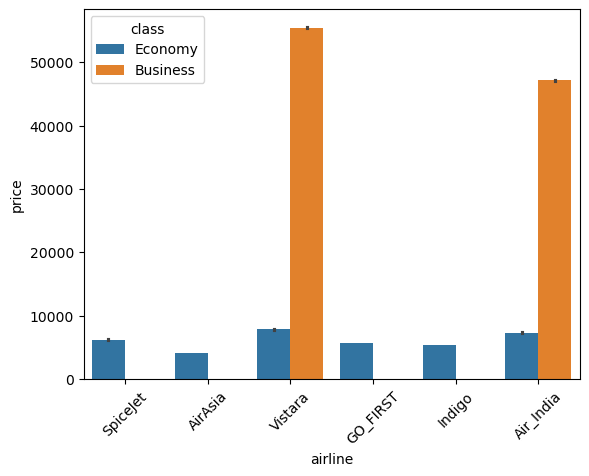

In [25]:
#Airline & Class combined

sns.barplot(x='airline', y='price', hue='class', data=df)
plt.xticks(rotation=45)
plt.show()


In [ ]:
Interpretation:-

Ticket prices vary by airline and travel class

Business class prices are much higher than economy across airlines

Pricing strategy differs between airlines

Key Findings:-

Vistara has the highest business class fares

Air India also shows high business class prices

Economy fares are lowest for AirAsia and Indigo

Travel class and airline together strongly affect price

In [26]:
#Source → Destination Pricing

route_price = df.groupby(['source_city','destination_city'])['price'].mean().reset_index()
route_price.head()


,source_city,destination_city,price
0,Bangalore,Chennai,23321.850078
1,Bangalore,Delhi,17723.313972
2,Bangalore,Hyderabad,21226.121192
3,Bangalore,Kolkata,23500.061229
4,Bangalore,Mumbai,23128.618672


9. Key Insights

Key Findings

Business class tickets are significantly more expensive than economy class

Non-stop flights have higher average ticket prices

Ticket prices increase as the travel date approaches

Certain airlines consistently offer lower average fares

Metro-to-metro routes are costlier compared to others

10. Conclusion

This EDA helped uncover important pricing patterns in airline ticket data. The insights can help travelers make cost-effective booking decisions and assist airlines in understanding customer behavior.